In [1]:
!python3.9 -m pip install matplotlib

     |████████████████████████████████| 8.3 MB 9.4 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 37.4 MB/s eta 0:00:01
     |████████████████████████████████| 66 kB 20.4 MB/s eta 0:00:011
     |████████████████████████████████| 19.5 MB 24.1 MB/s eta 0:00:01
     |████████████████████████████████| 4.8 MB 25.2 MB/s eta 0:00:01
     |████████████████████████████████| 229 kB 18.1 MB/s eta 0:00:01
     |████████████████████████████████| 7.6 MB 25.6 MB/s eta 0:00:01�▉              | 4.2 MB 25.6 MB/s eta 0:00:01
     |████████████████████████████████| 113 kB 34.1 MB/s eta 0:00:01
     |████████████████████████████████| 321 kB 38.8 MB/s eta 0:00:01


In [2]:
!python3.9 -m pip install nilearn

     |████████████████████████████████| 12.7 MB 9.1 MB/s eta 0:00:01
     |████████████████████████████████| 12.8 MB 46.1 MB/s eta 0:00:01
     |████████████████████████████████| 308 kB 26.4 MB/s eta 0:00:01
     |████████████████████████████████| 5.2 MB 22.2 MB/s eta 0:00:01
     |████████████████████████████████| 3.3 MB 21.1 MB/s eta 0:00:01
     |████████████████████████████████| 38.6 MB 21.9 MB/s eta 0:00:01
     |████████████████████████████████| 13.5 MB 35.9 MB/s eta 0:00:01
     |████████████████████████████████| 44 kB 10.2 MB/s eta 0:00:01
     |████████████████████████████████| 509 kB 38.8 MB/s eta 0:00:01
     |████████████████████████████████| 347 kB 24.6 MB/s eta 0:00:01


In [3]:
!python3.9 -m pip install seaborn

     |████████████████████████████████| 294 kB 8.5 MB/s eta 0:00:01


In [4]:
!pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 36.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 39.4 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nilearn.image as niimg
import nilearn.plotting as niplt
import os
from nilearn.image import resample_to_img
from nilearn import datasets
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

In [6]:
path = '/srv/tempdd/egermani/hcp_pipelines/data/derived/fsl_preprocessing/registration_fsl/'
participants = ["131823",'135124','118528']
#,"135124","118528"
fwhm_values = [5, 8]
hrf_derivatives = {"no": "no_derivatives","yes": "derivatives"}
nb_param_values = [0, 6, 24]
task = 'MOTOR'
contrasts = [1,2,3,4,5]

filename_template = (
    path +
    "_contrast_{contrast}_fwhm_{fwhm}_hrf_{hrf_full}_nb_param_{nb_param}_subject_id_{subject}_task_{task}" +
    "/_warpall_stat0/tstat{contrast}_warp.nii.gz"
)

loaded = {}

data_arrays = {}

for subj in participants:
    subj_key = f"s{subj}"
    loaded[subj_key] = {}
    data_arrays[subj_key] = {}
    
    for fwhm in fwhm_values:
        for hrf_short, hrf_full in hrf_derivatives.items():
            for nb_param in nb_param_values:

                pipeline_name = f"{subj_key}_fwhm{fwhm}_hrf{hrf_short}_param{nb_param}"
                loaded[subj_key][pipeline_name] = {}
                data_arrays[subj_key][pipeline_name] = {}

                for contrast in contrasts:

                    filename = filename_template.format(
                        subject=subj,
                        fwhm=fwhm,
                        hrf_full=hrf_full,
                        nb_param=nb_param,
                        task=task,
                        contrast=contrast
                    )

                    if not os.path.exists(filename):
                        print(f"Missing: {filename}")
                        continue
                        
                    img = niimg.load_img(filename)

                    loaded[subj_key][pipeline_name][contrast] = img
                    data_arrays[subj_key][pipeline_name][contrast] = img.get_fdata()

                    print(f"Loaded: {pipeline_name}_contrast{contrast}")


Loaded: s131823_fwhm5_hrfno_param0_contrast1
Loaded: s131823_fwhm5_hrfno_param0_contrast2
Loaded: s131823_fwhm5_hrfno_param0_contrast3
Loaded: s131823_fwhm5_hrfno_param0_contrast4
Loaded: s131823_fwhm5_hrfno_param0_contrast5
Loaded: s131823_fwhm5_hrfno_param6_contrast1
Loaded: s131823_fwhm5_hrfno_param6_contrast2
Loaded: s131823_fwhm5_hrfno_param6_contrast3
Loaded: s131823_fwhm5_hrfno_param6_contrast4
Loaded: s131823_fwhm5_hrfno_param6_contrast5
Loaded: s131823_fwhm5_hrfno_param24_contrast1
Loaded: s131823_fwhm5_hrfno_param24_contrast2
Loaded: s131823_fwhm5_hrfno_param24_contrast3
Loaded: s131823_fwhm5_hrfno_param24_contrast4
Loaded: s131823_fwhm5_hrfno_param24_contrast5
Loaded: s131823_fwhm5_hrfyes_param0_contrast1
Loaded: s131823_fwhm5_hrfyes_param0_contrast2
Loaded: s131823_fwhm5_hrfyes_param0_contrast3
Loaded: s131823_fwhm5_hrfyes_param0_contrast4
Loaded: s131823_fwhm5_hrfyes_param0_contrast5
Loaded: s131823_fwhm5_hrfyes_param6_contrast1
Loaded: s131823_fwhm5_hrfyes_param6_contrast

In [72]:
## old loading w/o registration
path = '/srv/tempdd/egermani/hcp_pipelines/data/derived/fsl_preprocessing/registration_fsl/'

participants = ["131823",'135124','118528']
#,"135124","118528"
fwhm_values = [5, 8]
hrf_derivatives = {"no": "no_derivatives","yes": "derivatives"}
nb_param_values = [0, 6, 24]
task = 'MOTOR'
contrasts = [1]

filename_template = (
    path +
    "_fwhm_{fwhm}_hrf_{hrf_full}_nb_param_{nb_param}_subject_id_{subject}_task_{task}"
    "/results/tstat{contrast}.nii.gz"
)

filename_fwhm5_hrfno_nbparam6 = (path + '_contrast_5_fwhm_8_hrf_no_derivatives_nb_param_6_subject_id_131823'
                                 + '_task_MOTOR/_warpall_stat0/' + 'tstat5_warp.nii.gz' )

loaded = {}

data_arrays = {}

for subj in participants:
    subj_key = f"s{subj}"
    loaded[subj_key] = {}
    data_arrays[subj_key] = {}
    
    for fwhm in fwhm_values:
        for hrf_short, hrf_full in hrf_derivatives.items():
            for nb_param in nb_param_values:

                pipeline_name = f"{subj_key}_fwhm{fwhm}_hrf{hrf_short}_param{nb_param}"
                loaded[subj_key][pipeline_name] = {}
                data_arrays[subj_key][pipeline_name] = {}

                for contrast in contrasts:

                    filename = filename_template.format(
                        subject=subj,
                        fwhm=fwhm,
                        hrf_full=hrf_full,
                        nb_param=nb_param,
                        task=task,
                        contrast=contrast
                    )

                    if not os.path.exists(filename):
                        print(f"Missing: {filename}")
                        continue
                        
                    img = niimg.load_img(filename)

                    loaded[subj_key][pipeline_name][contrast] = img
                    data_arrays[subj_key][pipeline_name][contrast] = img.get_fdata()

                    print(f"Loaded: {pipeline_name}_contrast{contrast}")


Loaded: s131823_fwhm5_hrfno_param0_contrast1
Loaded: s131823_fwhm5_hrfno_param6_contrast1
Loaded: s131823_fwhm5_hrfno_param24_contrast1
Loaded: s131823_fwhm5_hrfyes_param0_contrast1
Loaded: s131823_fwhm5_hrfyes_param6_contrast1
Loaded: s131823_fwhm5_hrfyes_param24_contrast1
Loaded: s131823_fwhm8_hrfno_param0_contrast1
Loaded: s131823_fwhm8_hrfno_param6_contrast1
Loaded: s131823_fwhm8_hrfno_param24_contrast1
Loaded: s131823_fwhm8_hrfyes_param0_contrast1
Loaded: s131823_fwhm8_hrfyes_param6_contrast1
Loaded: s131823_fwhm8_hrfyes_param24_contrast1
Loaded: s135124_fwhm5_hrfno_param0_contrast1
Loaded: s135124_fwhm5_hrfno_param6_contrast1
Loaded: s135124_fwhm5_hrfno_param24_contrast1
Loaded: s135124_fwhm5_hrfyes_param0_contrast1
Loaded: s135124_fwhm5_hrfyes_param6_contrast1
Loaded: s135124_fwhm5_hrfyes_param24_contrast1
Loaded: s135124_fwhm8_hrfno_param0_contrast1
Loaded: s135124_fwhm8_hrfno_param6_contrast1
Loaded: s135124_fwhm8_hrfno_param24_contrast1
Loaded: s135124_fwhm8_hrfyes_param0_con

In [73]:
#?? what is reference
pipeline = f"s{subj}_fwhm5_hrfno_param6"
contrast = 1  

In [74]:
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_img = atlas.maps
roi_labels = atlas.labels[1:]  
roi_indices = range(1, len(roi_labels) + 1)
roi_labels_dict = {idx: label for idx, label in zip(roi_indices, roi_labels)}

atlas_resampled = {}
atlas_arrays = {}

for subj in participants:
    subj_key = f"s{subj}"

    reference_pipeline = f"{subj_key}_fwhm5_hrfno_param6"

    ref_img = loaded[subj_key][reference_pipeline][1]

    resampled = resample_to_img(atlas_img, ref_img, interpolation="nearest")
    atlas_resampled[subj_key] = resampled
    atlas_arrays[subj_key] = resampled.get_fdata()

    print(f"Atlas resampled for {subj_key}")


Atlas resampled for s131823
Atlas resampled for s135124
Atlas resampled for s118528


In [75]:
roi_labels_dict

{1: 'Frontal Pole',
 2: 'Insular Cortex',
 3: 'Superior Frontal Gyrus',
 4: 'Middle Frontal Gyrus',
 5: 'Inferior Frontal Gyrus, pars triangularis',
 6: 'Inferior Frontal Gyrus, pars opercularis',
 7: 'Precentral Gyrus',
 8: 'Temporal Pole',
 9: 'Superior Temporal Gyrus, anterior division',
 10: 'Superior Temporal Gyrus, posterior division',
 11: 'Middle Temporal Gyrus, anterior division',
 12: 'Middle Temporal Gyrus, posterior division',
 13: 'Middle Temporal Gyrus, temporooccipital part',
 14: 'Inferior Temporal Gyrus, anterior division',
 15: 'Inferior Temporal Gyrus, posterior division',
 16: 'Inferior Temporal Gyrus, temporooccipital part',
 17: 'Postcentral Gyrus',
 18: 'Superior Parietal Lobule',
 19: 'Supramarginal Gyrus, anterior division',
 20: 'Supramarginal Gyrus, posterior division',
 21: 'Angular Gyrus',
 22: 'Lateral Occipital Cortex, superior division',
 23: 'Lateral Occipital Cortex, inferior division',
 24: 'Intracalcarine Cortex',
 25: 'Frontal Medial Cortex',
 26: '

In [76]:
for subj in participants:
    subj_key = f"s{subj}"
    atlas_shape = atlas_arrays[subj_key].shape

    print(f"\nSubject {subj_key}: Atlas shape = {atlas_shape}")

    for pipeline in loaded[subj_key]:
        for contrast in loaded[subj_key][pipeline]:
            t_shape = data_arrays[subj_key][pipeline][contrast].shape
            if t_shape != atlas_shape:
                print("SHAPE MISMATCH:", subj_key, pipeline, contrast, t_shape)
            else:
                print("MATCH:", pipeline, contrast)


Subject s131823: Atlas shape = (90, 104, 72)
MATCH: s131823_fwhm5_hrfno_param0 1
MATCH: s131823_fwhm5_hrfno_param6 1
MATCH: s131823_fwhm5_hrfno_param24 1
MATCH: s131823_fwhm5_hrfyes_param0 1
MATCH: s131823_fwhm5_hrfyes_param6 1
MATCH: s131823_fwhm5_hrfyes_param24 1
MATCH: s131823_fwhm8_hrfno_param0 1
MATCH: s131823_fwhm8_hrfno_param6 1
MATCH: s131823_fwhm8_hrfno_param24 1
MATCH: s131823_fwhm8_hrfyes_param0 1
MATCH: s131823_fwhm8_hrfyes_param6 1
MATCH: s131823_fwhm8_hrfyes_param24 1

Subject s135124: Atlas shape = (90, 104, 72)
MATCH: s135124_fwhm5_hrfno_param0 1
MATCH: s135124_fwhm5_hrfno_param6 1
MATCH: s135124_fwhm5_hrfno_param24 1
MATCH: s135124_fwhm5_hrfyes_param0 1
MATCH: s135124_fwhm5_hrfyes_param6 1
MATCH: s135124_fwhm5_hrfyes_param24 1
MATCH: s135124_fwhm8_hrfno_param0 1
MATCH: s135124_fwhm8_hrfno_param6 1
MATCH: s135124_fwhm8_hrfno_param24 1
MATCH: s135124_fwhm8_hrfyes_param0 1
MATCH: s135124_fwhm8_hrfyes_param6 1
MATCH: s135124_fwhm8_hrfyes_param24 1

Subject s118528: Atlas 

In [77]:
arr = data_arrays["s131823"]["s131823_fwhm5_hrfno_param6"][1]
print(arr.shape)

(90, 104, 72)


In [78]:
def parse_pipeline_name(pipeline_name):
    # example: "s116727_fwhm5_hrfno_param6"
    parts = pipeline_name.split("_")
    fwhm = int(parts[1].replace("fwhm",""))
    hrf = 0 if "hrfno" in parts[2] else 1
    motion_reg = int(parts[3].replace("param",""))
    return fwhm, hrf, motion_reg

In [79]:
## one ROI per df
rows = []
roi_data = {roi_idx: [] for roi_idx in range(1, len(roi_labels) + 1)}

for subj in participants:
    subj_key = f"s{subj}"

    atlas_flat = atlas_arrays[subj_key].flatten().astype(int)

    for pipeline in data_arrays[subj_key]:
        fwhm, hrf, motion_reg = parse_pipeline_name(pipeline)

        for contrast in data_arrays[subj_key][pipeline]:

            data_flat = data_arrays[subj_key][pipeline][contrast].flatten()

            n_vox = len(data_flat)

            # Create rows
            for voxel_index in range(n_vox):
                roi_idx = atlas_flat[voxel_index]  
                if roi_idx != 0: 
                    roi_data[roi_idx].append({
                        "voxel": voxel_index,
                        "roi": roi_idx,
                        "subj_id": subj,
                        "tvalue": float(data_flat[voxel_index]),
                        "fwhm": int(fwhm),
                        "motion_reg": int(motion_reg),
                        "hrf": int(hrf),
                        "contrast": int(contrast)
    })

In [80]:
roi_dfs = {
    f"roi_{roi_idx}": pd.DataFrame(rows)
    for roi_idx, rows in roi_data.items()
}

In [81]:
roi_dfs["roi_20"].head()

,voxel,roi,subj_id,tvalue,fwhm,motion_reg,hrf,contrast
0,83644,20,131823,0.0,5,0,0,1
1,83645,20,131823,0.0,5,0,0,1
2,83646,20,131823,0.0,5,0,0,1
3,83647,20,131823,0.0,5,0,0,1
4,83714,20,131823,0.0,5,0,0,1


In [82]:
#test for 1 roi

df = roi_dfs["roi_1"].copy()

df["subj_id"] = df["subj_id"].astype(str)
                                   
model = smf.mixedlm(
    "tvalue ~ fwhm + motion_reg + hrf",
    data=df,
    groups=df["subj_id"],
    re_formula="1"
)
result = model.fit()

results_table = pd.DataFrame({
    "coef": result.fe_params,
    "t_value": result.tvalues,
    "p_value": result.pvalues
})

# Apply FDR correction (BH procedure)
pvals = results_table["p_value"].values
reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

results_table["p_fdr"] = pvals_fdr
results_table["reject_fdr"] = reject

print(results_table)


                coef   t_value       p_value  p_fdr  reject_fdr
Group Var        NaN       NaN           NaN    NaN       False
Intercept   0.182880  0.137527  8.906145e-01    NaN       False
fwhm       -0.003006 -1.457374  1.450131e-01    NaN       False
hrf         0.010197  1.648074  9.933754e-02    NaN       False
motion_reg -0.002693 -8.876432  6.903934e-19    NaN        True


In [83]:
#fit for all ROIs and concatenate all results

all_results = []

for roi_name, df in roi_dfs.items():
    df = df.copy()
    df["subj_id"] = df["subj_id"].astype(str)
    
    model = smf.mixedlm(
        "tvalue ~ fwhm + motion_reg + hrf",
        data=df,
        groups=df["subj_id"],
        re_formula="1"
    )
    result = model.fit()
    
    results_table = pd.DataFrame({
        "coef": result.fe_params,
        "t_value": result.tvalues,
        "p_value": result.pvalues
    })
    
    # Apply FDR correction (BH procedure)
    pvals = results_table["p_value"].values
    reject, pvals_fdr, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
    results_table["p_fdr"] = pvals_fdr
    results_table["reject_fdr"] = reject
    
    results_table = results_table.reset_index()
    results_table.rename(columns={"index": "predictor"}, inplace=True)
    results_table["roi"] = roi_name
    
    all_results.append(results_table)

results_table_all = pd.concat(all_results, ignore_index=True)

In [84]:
results_table_all.groupby(by = ['predictor','reject_fdr']).count()

coef  t_value  p_value  p_fdr  roi
predictor  reject_fdr                                    
Group Var  False          0       36       36     36   48
Intercept  False         47       38       38     35   47
           True           1        1        1      1    1
fwhm       False         18        9        9      7   18
           True          30       30       30     29   30
hrf        False         29       20       20     18   29
           True          19       19       19     18   19
motion_reg False         34       25       25     24   34
           True          14       14       14     12   14

In [13]:
roi_labels = atlas.labels[1:]
roi_label_dict = {i+1: roi_labels[i] for i in range(len(roi_labels))}  # 1..N
roi_label_dict[0] = "Background"
df_voxels["roi_label"] = df_voxels["roi"].map(roi_label_dict)

In [14]:
df_voxels[df_voxels['roi']==1].head()

,voxel,roi,subj_id,tvalue,fwhm,motion_reg,hrf,contrast,roi_label
130999,130999,1,131823,0.464842,5,0,0,1,Frontal Pole
131000,131000,1,131823,0.897831,5,0,0,1,Frontal Pole
131001,131001,1,131823,1.755132,5,0,0,1,Frontal Pole
131071,131071,1,131823,1.043620,5,0,0,1,Frontal Pole
131072,131072,1,131823,2.274885,5,0,0,1,Frontal Pole


In [42]:
import sys
print(sys.version)

3.8.13 | packaged by conda-forge | (default, Mar 25 2022, 06:04:10) 
[GCC 10.3.0]


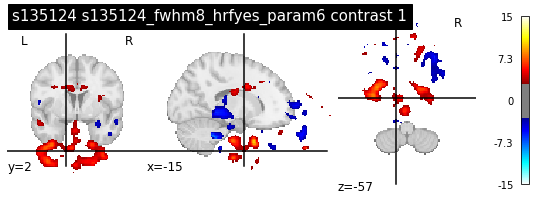

In [37]:
from nilearn import plotting

# subj_key = "s131823"
# pipeline_name = "s131823_fwhm8_hrfyes_param6"
subj_key = "s135124"
pipeline_name = "s135124_fwhm8_hrfyes_param6"
contrast = 1  # pick which contrast to plot

# Load the Nifti image
img = loaded[subj_key][pipeline_name][contrast]

# Plot it
plotting.plot_stat_map(
    img,
    threshold=3.0,
#     bg_img=None,
    display_mode='ortho',
    title=f"{subj_key} {pipeline_name} contrast {contrast}"
)
plotting.show()

In [38]:
mni_template = datasets.load_mni152_template()

In [39]:
mni_template.affine

array([[   2.,    0.,    0.,  -98.],
       [   0.,    2.,    0., -134.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])

In [40]:
img.affine

array([[-1.99638152e+00, -7.47586275e-03,  1.20019779e-01,
         8.40119171e+01],
       [-2.57339943e-02,  1.97644818e+00, -3.04943204e-01,
        -4.40686722e+01],
       [ 1.17466576e-01,  3.05935800e-01,  1.97296846e+00,
        -1.09256882e+02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [41]:
from nilearn import image

resampled_img = image.resample_to_img(img, mni_template)


In [42]:
mni_template.shape

(99, 117, 95)

In [43]:
img.shape

(90, 104, 72)

In [44]:
resampled_img.shape

(99, 117, 95)

In [71]:
# anat_img = image.load_img("/srv/tempdd/egermani/hcp_pipelines/data/original/135124/unprocessed/3T/T1w_MPR1/135124_3T_T1w_MPR1.nii.gz")

anat_img = image.load_img("/srv/tempdd/egermani/hcp_pipelines/data/derived/fsl_preprocessing/preprocess_fsl/_fwhm_8_subject_id_135124_task_MOTOR/135124_3T_T1w_MPR1_fieldwarp.nii.gz")

anat_img.shape

# import os
# os.listdir("/srv/tempdd/egermani/hcp_pipelines/data/derived/fsl_preprocessing/preprocess_fsl/_fwhm_8_subject_id_135124_task_MOTOR")


(21, 24, 21, 3)

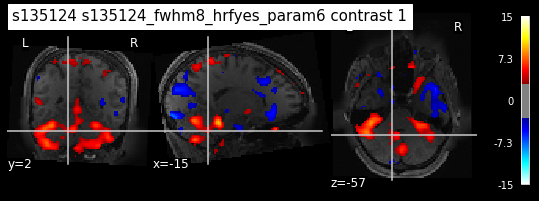

In [53]:
plotting.plot_stat_map(
    img,
    threshold=3.0,
    bg_img=anat_img_resamp,
    display_mode='ortho',
    title=f"{subj_key} {pipeline_name} contrast {contrast}"
)

In [55]:
!pip install niflow-nipype1-workflows

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.3/491.3 kB 32.6 MB/s eta 0:00:00
  Attempting uninstall: etelemetry
    Found existing installation: etelemetry 0+unknown
    Uninstalling etelemetry-0+unknown:
      Successfully uninstalled etelemetry-0+unknown


In [56]:
from niflow.nipype1.workflows.fmri.fsl import create_reg_workflow
from nipype.interfaces.fsl import Info

reg = create_reg_workflow()
reg.inputs.inputspec.target_image = Info.standard_image('MNI152_T1_2mm_brain.nii.gz')
reg.inputs.inputspec.target_image_brain = Info.standard_image('MNI152_T1_2mm_brain.nii.gz')

reg

registration

In [58]:
reg.inputs.inputspec.anatomical_image = "/srv/tempdd/egermani/hcp_pipelines/data/original/135124/unprocessed/3T/T1w_MPR1/135124_3T_T1w_MPR1.nii.gz"
reg.inputs.inputspec.source_files = "/srv/tempdd/egermani/hcp_pipelines/data/"


anatomical_image = <undefined>
config_file = <undefined>
mean_image = <undefined>
source_files = <undefined>
target_image = /opt/fsl-6.0.3/data/standard/MNI152_T1_2mm_brain.nii.gz
target_image_brain = /opt/fsl-6.0.3/data/standard/MNI152_T1_2mm_brain.nii.gz

In [3]:
tvals = data_arrays[subj_key][pipeline_name][contrast]  # numpy array (X×Y×Z)
atlas_vox = atlas_arrays[subj_key]                      # numpy array (X×Y×Z)

NameError: name 'atlas_arrays' is not defined

In [ ]:
import pandas as pd
import numpy as np

def parse_pipeline_name(pipeline_name):
    # example: "s116727_fwhm5_hrfno_param6"
    parts = pipeline_name.split("_")
    fwhm = int(parts[1].replace("fwhm",""))
    hrf = 0 if "hrfno" in parts[2] else 1
    motion_reg = int(parts[3].replace("param",""))
    return fwhm, hrf, motion_reg


all_dfs = {}   # store each subj/pipeline DF separately


for subj in participants:
    subj_key = f"s{subj}"

    # flat atlas for this subject (after resampling)
    atlas_flat = atlas_arrays[subj_key].astype(int).flatten()

    for pipeline in data_arrays[subj_key]:

        fwhm, hrf, motion_reg = parse_pipeline_name(pipeline)

        for contrast in data_arrays[subj_key][pipeline]:

            # extract 3D stat map and flatten
            t_flat = data_arrays[subj_key][pipeline][contrast].flatten()

            # number of voxels
            n_vox = len(t_flat)

            # create dataframe in ONE operation
            df = pd.DataFrame({
                "voxel": np.arange(n_vox),
                "roi": atlas_flat,
                "subj_id": subj,
                "tvalue": t_flat.astype(float),
                "fwhm": fwhm,
                "motion_reg": motion_reg,
                "hrf": hrf,
                "contrast": str(contrast)
            })

            key = f"{subj_key}_{pipeline}_contrast{contrast}"
            all_dfs[key] = df

            print(f"Created DF: {key}, shape={df.shape}")
